Fase inicial de criação e configuração do ambiente para um modelo gernérico, multi-ação.

In [15]:
# ===========================
# Fase 0 — Configurações
# Modelo genérico multi-ação
# ===========================

from pathlib import Path
import os

# ---- Fonte de dados e chaves ----
USE_ALPHA_FIRST = True                            # tenta Alpha Vantage antes do CSV
ALPHAVANTAGE_API_KEY = os.getenv("ALPHAVANTAGE_API_KEY")  # defina no ambiente quando usar Alpha

# ---- Universo de treino (multi-ação) ----
# Misture tickers de mercados diferentes para generalizar padrões.
TICKERS = [
    "AAPL", "MSFT", "AMZN",            # EUA
    "PETR4.SA", "VALE3.SA", "ITUB4.SA" # B3 (usa .SA)
]

START_DATE = "2018-01-01"
END_DATE   = None                      # até hoje

# ---- Janelas e partições ----
LOOKBACK  = 60         # janela temporal
TEST_SIZE = 0.20       # fração para teste (final da série)
VAL_SIZE  = 0.10       # fração para validação (dentro do treino)
RANDOM_SEED = 42

# ---- Treino (ajuste rápido / smoke test) ----
EPOCHS     = 50
BATCH_SIZE = 64

# ---- Estrutura de diretórios (agnóstico ao local de execução) ----
# Se estiver rodando o notebook dentro de "notebook/", ele criará "notebook/data" etc.
ROOT_DIR      = Path.cwd()
DATA_DIR      = ROOT_DIR / "data"
MODELS_DIR    = ROOT_DIR / "models"
ARTIFACTS_DIR = ROOT_DIR / "artifacts"
LOG_DIR       = ROOT_DIR / "logs"

for d in (DATA_DIR, MODELS_DIR, ARTIFACTS_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Nomes de saída (modelo genérico) ----
MODEL_NAME  = "lstm_generic"                       # um único modelo para todos os ativos
MODEL_PATH  = MODELS_DIR / f"{MODEL_NAME}.keras"
SCALER_PATH = ARTIFACTS_DIR / "scaler_generic.joblib"

# ---- Mensagem de contexto ----
print("=== Fase 0: Configurações carregadas ===")
print(f"Fonte preferencial Alpha Vantage: {USE_ALPHA_FIRST} | API_KEY set? {bool(ALPHAVANTAGE_API_KEY)}")
print(f"Tickers (treino multi-ação): {TICKERS}")
print(f"Período: {START_DATE} → {END_DATE or 'hoje'}")
print(f"LOOKBACK={LOOKBACK} | TEST={TEST_SIZE} | VAL={VAL_SIZE} | EPOCHS={EPOCHS} | BATCH_SIZE={BATCH_SIZE}")
print(f"DATA_DIR={DATA_DIR}")
print(f"MODEL_PATH={MODEL_PATH}")
print(f"SCALER_PATH={SCALER_PATH}")


=== Fase 0: Configurações carregadas ===
Fonte preferencial Alpha Vantage: True | API_KEY set? True
Tickers (treino multi-ação): ['AAPL', 'MSFT', 'AMZN', 'PETR4.SA', 'VALE3.SA', 'ITUB4.SA']
Período: 2018-01-01 → hoje
LOOKBACK=60 | TEST=0.2 | VAL=0.1 | EPOCHS=50 | BATCH_SIZE=64
DATA_DIR=d:\Tech\tech4-1\data
MODEL_PATH=d:\Tech\tech4-1\models\lstm_generic.keras
SCALER_PATH=d:\Tech\tech4-1\artifacts\scaler_generic.joblib


Fase 1  - Coleta de dados

In [16]:
# ===========================
# Fase 1 — Coleta & Cache (Alpha → CSV)
# Multi-ação: TICKERS definidos na Fase 0
# ===========================
from alpha_vantage.timeseries import TimeSeries
import pandas as pd
from pathlib import Path
import os

assert 'TICKERS' in globals(), "Defina TICKERS na Fase 0."
assert 'DATA_DIR' in globals(), "Defina DATA_DIR na Fase 0."
assert 'START_DATE' in globals(), "Defina START_DATE na Fase 0."
assert 'USE_ALPHA_FIRST' in globals(), "Defina USE_ALPHA_FIRST na Fase 0."

API_KEY = ALPHAVANTAGE_API_KEY if 'ALPHAVANTAGE_API_KEY' in globals() else os.getenv("ALPHAVANTAGE_API_KEY")

def _csv_path(ticker: str) -> Path:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    return DATA_DIR / f"{ticker}.csv"

def _read_local_csv(ticker: str) -> pd.DataFrame | None:
    p = _csv_path(ticker)
    if p.exists():
        df = pd.read_csv(p, parse_dates=["Date"])
        if "Close" not in df.columns:
            raise ValueError(f"CSV local {p} não possui coluna 'Close'.")
        return (df.sort_values("Date")
                  .reset_index(drop=True))
    return None

def _fetch_alpha_to_csv(ticker: str, start_date: str) -> pd.DataFrame:
    """Baixa via Alpha Vantage (se API_KEY existir), converte colunas e salva em CSV (cache)."""
    if not API_KEY:
        raise RuntimeError("ALPHAVANTAGE_API_KEY não definida no ambiente.")
    ts = TimeSeries(key=API_KEY, output_format='pandas')
    # daily, outputsize full (respeite 5 req/min do plano gratuito)
    data, meta = ts.get_daily(symbol=ticker, outputsize='full')
    data = (data.rename(columns={
        '1. open':'Open','2. high':'High','3. low':'Low',
        '4. close':'Close','5. volume':'Volume'
    })
    .reset_index()
    .rename(columns={'date':'Date'}))
    data = data[data['Date'] >= pd.to_datetime(start_date)]
    data = data.sort_values("Date").reset_index(drop=True)

    # Salva no cache local
    path = _csv_path(ticker)
    data.to_csv(path, index=False)
    print(f"[alpha] {ticker}: {len(data)} linhas | salvo em {path}")
    return data

def get_or_fetch(ticker: str, start_date: str) -> pd.DataFrame:
    """Ordem: Alpha (se permitido) → CSV local. Lança erro se nada disponível."""
    # Tenta Alpha primeiro?
    if USE_ALPHA_FIRST:
        try:
            return _fetch_alpha_to_csv(ticker, start_date)
        except Exception as e:
            print(f"[alpha] falhou ({ticker}): {e}. Tentando CSV local…")
            df = _read_local_csv(ticker)
            if df is not None and not df.empty:
                print(f"[csv] usando cache local para {ticker}: {len(df)} linhas")
                return df
            raise

    # Caso contrário, prefira CSV local
    df = _read_local_csv(ticker)
    if df is not None and not df.empty:
        print(f"[csv] usando cache local para {ticker}: {len(df)} linhas")
        return df

    # Último recurso: Alpha
    return _fetch_alpha_to_csv(ticker, start_date)

# ---- Carrega todos os tickers definidos na Fase 0 ----
DATA_BY_TICKER: dict[str, pd.DataFrame] = {}
for t in TICKERS:
    print(f"==> Carregando {t} …")
    df_t = get_or_fetch(t, START_DATE)
    # sanity check mínimo
    cols_min = {"Date","Open","High","Low","Close","Volume"}
    if not cols_min.issubset(set(df_t.columns)):
        raise ValueError(f"{t}: CSV sem colunas mínimas {cols_min}.")
    if df_t["Close"].isna().all():
        raise ValueError(f"{t}: coluna Close vazia.")
    DATA_BY_TICKER[t] = df_t

# ---- Sumário rápido ----
SUMMARY = pd.DataFrame({
    "Ticker": list(DATA_BY_TICKER.keys()),
    "Rows": [len(df) for df in DATA_BY_TICKER.values()],
    "Start": [df["Date"].min() for df in DATA_BY_TICKER.values()],
    "End":   [df["Date"].max() for df in DATA_BY_TICKER.values()],
})
print("\n=== RESUMO DOS DADOS CARREGADOS ===")
display(SUMMARY)


==> Carregando AAPL …
[alpha] falhou (AAPL): We have detected your API key as MJG5FFYWD6JGEQSA and our standard API rate limit is 25 requests per day. Please subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly remove all daily rate limits.. Tentando CSV local…
[csv] usando cache local para AAPL: 1983 linhas
==> Carregando MSFT …
[alpha] falhou (MSFT): We have detected your API key as MJG5FFYWD6JGEQSA and our standard API rate limit is 25 requests per day. Please subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly remove all daily rate limits.. Tentando CSV local…
[csv] usando cache local para MSFT: 1983 linhas
==> Carregando AMZN …
[alpha] falhou (AMZN): We have detected your API key as MJG5FFYWD6JGEQSA and our standard API rate limit is 25 requests per day. Please subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly remove all daily rate limits.. Tentando CSV local…
[csv

,Ticker,Rows,Start,End
0,AAPL,1983,2018-01-02,2025-11-19
1,MSFT,1983,2018-01-02,2025-11-19
2,AMZN,1983,2018-01-02,2025-11-19
3,PETR4.SA,1962,2018-01-02,2025-11-19
4,VALE3.SA,1962,2018-01-02,2025-11-19
5,ITUB4.SA,1962,2018-01-02,2025-11-19


Fase 2 - Preparando o modelo para rodar com várias ações

In [17]:
# Validação dos valores
import numpy as np
# Validações rápidas por ticker — checa presença de colunas, NaNs, duplicatas de Date, volumes negativos e Close não-finitos.
assert 'DATA_BY_TICKER' in globals(), "Execute a Fase 1 antes."

required_cols = globals().get('cols_min', {"Date","Open","High","Low","Close","Volume"})

rows = []
for t, df in DATA_BY_TICKER.items():
    info = {"Ticker": t, "Rows": len(df)}
    # colunas faltantes
    missing_cols = [c for c in required_cols if c not in df.columns]
    info["MissingCols"] = missing_cols
    # contagem de NaNs por coluna (apenas para colunas presentes)
    present_required = [c for c in required_cols if c in df.columns]
    null_counts = df[present_required].isna().sum().to_dict()
    info["NullCounts"] = null_counts
    info["TotalNulls"] = int(df[present_required].isna().sum().sum())
    # Date dtype e duplicatas
    if "Date" in df.columns:
        info["DateDtype"] = str(df["Date"].dtype)
        info["DuplicateDates"] = int(df["Date"].duplicated().sum())
    else:
        info["DateDtype"] = "missing"
        info["DuplicateDates"] = None
    # Volume negativo?
    if "Volume" in df.columns:
        info["AnyNegativeVolume"] = bool((df["Volume"] < 0).any())
    else:
        info["AnyNegativeVolume"] = None
    # Close finite?
    if "Close" in df.columns:
        info["CloseAllFinite"] = bool(np.isfinite(df["Close"]).all())
    else:
        info["CloseAllFinite"] = None
    # regra simples de "tudo OK"
    info["AllGood"] = (
        len(missing_cols) == 0
        and info["TotalNulls"] == 0
        and (info["DuplicateDates"] == 0 or info["DuplicateDates"] is None)
        and (info["AnyNegativeVolume"] is False or info["AnyNegativeVolume"] is None)
        and (info["CloseAllFinite"] is True or info["CloseAllFinite"] is None)
    )
    rows.append(info)

summary_check = pd.DataFrame(rows).set_index("Ticker")
display(summary_check)

# Mostra amostras de problemas (até 5 linhas) para inspeção rápida
for t, df in DATA_BY_TICKER.items():
    problems = []
    if any(c in df.columns and df[c].isna().any() for c in required_cols):
        problems.append("NaNs")
    if "Date" in df.columns and df["Date"].duplicated().any():
        problems.append("DuplicateDates")
    if "Volume" in df.columns and (df["Volume"] < 0).any():
        problems.append("NegativeVolume")
    if "Close" in df.columns and not np.isfinite(df["Close"]).all():
        problems.append("NonFiniteClose")

    if problems:
        print(f"\n==> {t} — problemas detectados: {problems}")
        if df.columns.isin(required_cols).any():
            print("Amostra linhas com NaNs (até 5):")
            display(df[df[required_cols.intersection(df.columns)].isna().any(axis=1)].head(5))
        if "Date" in df.columns and df["Date"].duplicated().any():
            print("Linhas duplicadas por Date (até 5):")
            display(df[df["Date"].duplicated(keep=False)].sort_values("Date").head(5))
        if "Volume" in df.columns and (df["Volume"] < 0).any():
            print("Linhas com Volume negativo (até 5):")
            display(df[df["Volume"] < 0].head(5))
        if "Close" in df.columns and not np.isfinite(df["Close"]).all():
            print("Linhas com Close não-finito (até 5):")
            display(df[~np.isfinite(df["Close"])].head(5))

# Sumariza status final
n_bad = (~summary_check["AllGood"]).sum()
if n_bad == 0:
    print("\n✅ Todas as séries parecem OK (sem colunas faltantes, sem NaNs, sem duplicatas de Date, Close finito, Volume não-negativo).")
else:
    print(f"\n⚠️ {n_bad} ticker(s) com problemas — verifique a saída acima.")

,Rows,MissingCols,NullCounts,TotalNulls,DateDtype,DuplicateDates,AnyNegativeVolume,CloseAllFinite,AllGood
Ticker,,,,,,,,,
AAPL,1983,[],"{'Open': 0, 'Date': 0, 'Low': 0, 'Volume': 0, ...",0,datetime64[ns],0,False,True,True
MSFT,1983,[],"{'Open': 0, 'Date': 0, 'Low': 0, 'Volume': 0, ...",0,datetime64[ns],0,False,True,True
AMZN,1983,[],"{'Open': 0, 'Date': 0, 'Low': 0, 'Volume': 0, ...",0,datetime64[ns],0,False,True,True
PETR4.SA,1962,[],"{'Open': 0, 'Date': 0, 'Low': 0, 'Volume': 0, ...",0,datetime64[ns],0,False,True,True
VALE3.SA,1962,[],"{'Open': 0, 'Date': 0, 'Low': 0, 'Volume': 0, ...",0,datetime64[ns],0,False,True,True
ITUB4.SA,1962,[],"{'Open': 0, 'Date': 0, 'Low': 0, 'Volume': 0, ...",0,datetime64[ns],0,False,True,True



✅ Todas as séries parecem OK (sem colunas faltantes, sem NaNs, sem duplicatas de Date, Close finito, Volume não-negativo).


In [19]:
# ===========================
# Fase 2 — Preparação (Multi-ação + Volume + RSI + Scaling Individual)
# ===========================
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import joblib

assert 'DATA_BY_TICKER' in globals(), "Rode a Fase 1 antes."
assert 'LOOKBACK' in globals(), "Defina LOOKBACK na Fase 0."
np.random.seed(RANDOM_SEED)

# --- Função RSI ---
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# --- Função de Janelamento ---
def make_windowed_multivariate(df_scaled, lookback: int):
    """
    Entrada: DataFrame ['Close_scaled', 'Vol_scaled', 'RSI_scaled']
    Saída: X (N, lookback, 3), y (N, 1)
    """
    data = df_scaled.values # (N, 3)
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i]) # 3 features
        y.append(data[i, 0])         # Target é Close (col 0)
    
    X = np.array(X)
    y = np.array(y).reshape(-1, 1)
    return X, y

def time_series_split_by_fraction(X, y, test_frac, val_frac):
    n = len(X)
    n_test = int(n * test_frac)
    n_trainval = n - n_test
    n_val = int(n_trainval * val_frac)
    n_train = n_trainval - n_val
    return (X[:n_train], y[:n_train]), (X[n_train:n_train+n_val], y[n_train:n_train+n_val]), (X[n_train+n_val:], y[n_train+n_val:])

# --- Processamento Principal ---
scalers_by_ticker = {} 
dfs_scaled_list = []

X_tr_list, y_tr_list = [], []
X_va_list, y_va_list = [], []
X_te_list, y_te_list = [], []

print("Processando tickers...")

for t, df_orig in DATA_BY_TICKER.items():
    # 1. Copia e calcula RSI
    df_t = df_orig[['Date','Close','Volume']].copy()
    df_t['Ticker'] = t
    df_t['RSI'] = calculate_rsi(df_t['Close'], period=14).fillna(50)
    
    # 2. Escalonamento INDIVIDUAL (Per-Ticker)
    sc_close = MinMaxScaler()
    sc_vol   = MinMaxScaler()
    sc_rsi   = MinMaxScaler()
    
    # Log no volume para reduzir outliers
    vol_log = np.log1p(df_t[['Volume']])
    
    # Fit & Transform
    df_t['Close_scaled'] = sc_close.fit_transform(df_t[['Close']])
    df_t['Vol_scaled']   = sc_vol.fit_transform(vol_log)
    df_t['RSI_scaled']   = sc_rsi.fit_transform(df_t[['RSI']])
    
    # Guarda scalers
    scalers_by_ticker[t] = {'close': sc_close, 'vol': sc_vol, 'rsi': sc_rsi}
    dfs_scaled_list.append(df_t)
    
    # 3. Gera Janelas
    sub_scaled = df_t[['Close_scaled', 'Vol_scaled', 'RSI_scaled']]
    if len(sub_scaled) <= LOOKBACK + 20: 
        continue

    X_t, y_t = make_windowed_multivariate(sub_scaled, lookback=LOOKBACK)
    
    # 4. Split Temporal
    (X_tr, y_tr), (X_va, y_va), (X_te, y_te) = time_series_split_by_fraction(
        X_t, y_t, test_frac=TEST_SIZE, val_frac=VAL_SIZE
    )

    X_tr_list.append(X_tr); y_tr_list.append(y_tr)
    X_va_list.append(X_va); y_va_list.append(y_va)
    X_te_list.append(X_te); y_te_list.append(y_te)

# Concatena tudo
df_all = pd.concat(dfs_scaled_list, ignore_index=True).sort_values(['Ticker','Date']).reset_index(drop=True)

def _cat(xs): return np.concatenate(xs, axis=0) if len(xs) else np.empty((0, LOOKBACK, 3))
def _cat_y(ys): return np.concatenate(ys, axis=0) if len(ys) else np.empty((0, 1))

X_train, y_train = _cat(X_tr_list), _cat_y(y_tr_list)
X_val,   y_val   = _cat(X_va_list), _cat_y(y_va_list)
X_test,  y_test  = _cat(X_te_list), _cat_y(y_te_list)

print("=== Shapes Finais (3 Features: Close, Vol, RSI) ===")
print("X_train:", X_train.shape)
print("Scalers individuais criados para:", list(scalers_by_ticker.keys()))

Processando tickers...
=== Shapes Finais (3 Features: Close, Vol, RSI) ===
X_train: (8268, 60, 3)
Scalers individuais criados para: ['AAPL', 'MSFT', 'AMZN', 'PETR4.SA', 'VALE3.SA', 'ITUB4.SA']


In [20]:
# Callback para métricas em unidades originais (preço) por época — usa amostra para não ficar lento
from tensorflow.keras.callbacks import Callback
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

class OrigScaleMetrics(Callback):
    def __init__(self, X_train, y_train, X_val, y_val, scaler_close, sample_size=1024, every_n_epochs=1):
        super().__init__()
        # mantém apenas uma amostra para cada conjunto (evita custo alto por época)
        self.X_train = X_train[:sample_size]
        self.y_train = y_train[:sample_size]
        self.X_val = X_val[:sample_size]
        self.y_val = y_val[:sample_size]
        self.scaler_close = scaler_close
        self.every = every_n_epochs
        self.train_mae = []
        self.val_mae = []
        self.train_rmse = []
        self.val_rmse = []

    def _to_orig(self, y_scaled):
        arr = np.asarray(y_scaled).reshape(-1, 1)
        return self.scaler.inverse_transform(arr).reshape(-1)

    def on_epoch_end(self, epoch, logs=None):
        # registra a cada `every` épocas
        if (epoch + 1) % self.every != 0:
            return
        try:
            yp_train = self.model.predict(self.X_train, verbose=0)
            yp_val = self.model.predict(self.X_val, verbose=0)
            ytr_orig = self._to_orig(self.y_train)
            ypv_orig = self._to_orig(yp_train)
            yv_orig = self._to_orig(self.y_val)
            ypv_val_orig = self._to_orig(yp_val)

            train_mae = mean_absolute_error(ytr_orig, ypv_orig)
            val_mae = mean_absolute_error(yv_orig, ypv_val_orig)
            train_rmse = mean_squared_error(ytr_orig, ypv_orig, squared=False)
            val_rmse = mean_squared_error(yv_orig, ypv_val_orig, squared=False)

            self.train_mae.append(train_mae)
            self.val_mae.append(val_mae)
            self.train_rmse.append(train_rmse)
            self.val_rmse.append(val_rmse)

            # opcional: coloca no logs para aparecer em `history.history` se desejar
            if logs is not None:
                logs['train_mae_orig'] = train_mae
                logs['val_mae_orig'] = val_mae
        except Exception as e:
            print('OrigScaleMetrics erro:', e)

# instância do callback (usa tamanho de amostra controlado)
orig_cb = OrigScaleMetrics(X_train, y_train, X_val, y_val, scaler_close, sample_size=1024, every_n_epochs=1)


Fase 3 - Modelagem e treino

In [21]:
# ===========================
# Fase 3 — Modelagem (3 Features)
# ===========================
import os
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import Huber

# Assert atualizado para 3 features
assert X_train.shape[2] == 3, f"Esperado 3 features, recebido {X_train.shape[2]}"

def build_lstm_model(lookback: int = 60):
    model = Sequential([
        # input_shape=(lookback, 3)
        LSTM(96, return_sequences=True, input_shape=(lookback, 3), recurrent_dropout=0.1),
        LayerNormalization(),
        Dropout(0.2),
        LSTM(64, recurrent_dropout=0.1),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss=Huber(delta=1.0))
    return model

model = build_lstm_model(LOOKBACK)
model.summary()

ckpt_path = str(MODEL_PATH.with_name(f"{MODEL_PATH.stem}_rsi_ckpt.keras"))
es  = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=31, min_lr=1e-5, verbose=1)
ckp = ModelCheckpoint(filepath=ckpt_path, monitor="val_loss", save_best_only=True, verbose=1)

# Reinstancia callback com scaler correto
orig_cb = OrigScaleMetrics(X_train, y_train, X_val, y_val, scaler_close, sample_size=1024)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rlr, ckp, orig_cb],
    verbose=1,
)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 60, 96)            38400     
                                                                 
 layer_normalization_1 (Laye  (None, 60, 96)           192       
 rNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 60, 96)            0         
                                                                 
 lstm_3 (LSTM)               (None, 64)                41216     
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 79,873
Trainable params: 79,873
Non-trainable params: 0
__________________________________________________

In [22]:
# Plot das métricas em unidades originais coletadas pelo OrigScaleMetrics durante o treino (se disponível)
try:
    if 'orig_cb' in globals() and len(orig_cb.train_mae) > 0:
        import matplotlib.pyplot as plt
        epochs_range = range(1, len(orig_cb.train_mae) + 1)
        plt.figure()
        plt.plot(epochs_range, orig_cb.train_mae, label='train MAE (orig)')
        plt.plot(epochs_range, orig_cb.val_mae, label='val MAE (orig)')
        plt.title('MAE em unidades originais por época')
        plt.xlabel('Epoch')
        plt.ylabel('MAE (preço)')
        plt.legend()
        plt.show()
    else:
        print('orig_cb metrics não disponíveis (callback não usado ou sem épocas registradas).')
except Exception as e:
    print('Erro ao plotar métricas originais:', e)


orig_cb metrics não disponíveis (callback não usado ou sem épocas registradas).


In [23]:
# DEBUG: checagem rápida de shapes e consistência antes da avaliação
import numpy as np
import os
import pandas as pd

def _report_arr(name, arr):
    try:
        a = np.asarray(arr)
        info = {
            'shape': getattr(a, 'shape', None),
            'ndim': getattr(a, 'ndim', None),
            'dtype': str(getattr(a, 'dtype', None)),
        }
        print(f"{name}: shape={info['shape']}, ndim={info['ndim']}, dtype={info['dtype']}")
        # NaN/Inf checks for numeric arrays
        if np.issubdtype(a.dtype, np.number):
            print(f"  any_nan={np.isnan(a).any()}, any_inf={np.isinf(a).any()}")
    except Exception as e:
        print(f"{name}: erro ao inspecionar -> {e}")

print('\n=== Relatório rápido de consistência ===')
for var in ['X_train','y_train','X_val','y_val','X_test','y_test','df_all','scaler']:
    if var in globals():
        _report_arr(var, globals().get(var))
    else:
        print(f"{var}: NÃO DEFINIDO")

# Checa capacidade de predição do modelo (previsão de amostra)
try:
    if 'model' in globals() and 'X_test' in globals() and getattr(X_test, 'shape', (0,))[0] > 0:
        pred_shape = model.predict(X_test[:1]).shape
        print(f"model.predict(sample) -> shape: {pred_shape}")
    else:
        print('model ou X_test indisponível para predict de teste')
except Exception as e:
    print('model.predict disparou erro:', e)

# Scaler / paths
try:
    print('SCALER_PATH:', SCALER_PATH)
    print('scaler variable is object:', type(globals().get('scaler')))
    print('scaler file exists on disk:', os.path.exists(str(SCALER_PATH)))
except Exception as e:
    print('Erro ao checar SCALER_PATH:', e)

# Mostra resumo de NaNs no df_all (se existir)
if 'df_all' in globals():
    try:
        print('\nResumo de NaNs em df_all (por coluna):')
        print(df_all.isna().sum().to_dict())
    except Exception as e:
        print('Erro ao resumir df_all:', e)

print('\n=== Fim do relatório ===\n')



=== Relatório rápido de consistência ===
X_train: shape=(8268, 60, 3), ndim=3, dtype=float64
  any_nan=False, any_inf=False
y_train: shape=(8268, 1), ndim=2, dtype=float64
  any_nan=False, any_inf=False
X_val: shape=(915, 60, 3), ndim=3, dtype=float64
  any_nan=False, any_inf=False
y_val: shape=(915, 1), ndim=2, dtype=float64
  any_nan=False, any_inf=False
X_test: shape=(2292, 60, 3), ndim=3, dtype=float64
  any_nan=False, any_inf=False
y_test: shape=(2292, 1), ndim=2, dtype=float64
  any_nan=False, any_inf=False
df_all: shape=(11835, 8), ndim=2, dtype=object
scaler: NÃO DEFINIDO
1/1 [==============================] - 0s 270ms/step
model.predict(sample) -> shape: (1, 1)
SCALER_PATH: d:\Tech\tech4-1\artifacts\scaler_generic.joblib
scaler variable is object: <class 'NoneType'>
scaler file exists on disk: True

Resumo de NaNs em df_all (por coluna):
{'Date': 0, 'Close': 0, 'Volume': 0, 'Ticker': 0, 'RSI': 0, 'Close_scaled': 0, 'Vol_scaled': 0, 'RSI_scaled': 0}

=== Fim do relatório ===



Fase 4 - Avaliação e Salvamento

=== Avaliando performance na PETR4.SA ===
MAE (PETR4.SA): 0.6138


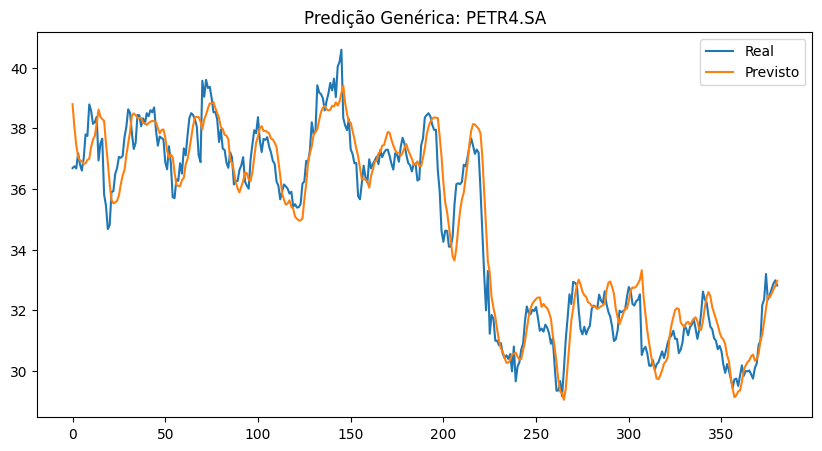

✅ Modelo salvo em: d:\Tech\tech4-1\models\lstm_generic.keras
✅ Dicionário de Scalers salvo em: d:\Tech\tech4-1\artifacts\scalers_dict.joblib


In [24]:
# ===========================
# Fase 4 — Avaliação Focada & Salvamento
# ===========================
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 1. Avaliação em um Ticker Específico (ex: PETR4) para validar
TICKER_EVAL = "PETR4.SA" 
# Se quiser testar uma "nova", poderia pegar um ticker que não entrou no treino, 
# mas teria que baixar os dados e criar o scaler dele aqui.

if TICKER_EVAL in scalers_by_ticker:
    print(f"=== Avaliando performance na {TICKER_EVAL} ===")
    
    # Recupera dados e scaler
    df_eval = df_all[df_all['Ticker'] == TICKER_EVAL].copy()
    scaler_eval = scalers_by_ticker[TICKER_EVAL]['close'] # Scaler específico
    
    # Gera janelas
    X_eval, y_eval = make_windowed_multivariate(
        df_eval[['Close_scaled', 'Vol_scaled', 'RSI_scaled']], 
        lookback=LOOKBACK
    )
    
    # Pega só o final (teste)
    split_idx = int(len(X_eval) * (1 - TEST_SIZE))
    X_test_eval = X_eval[split_idx:]
    y_test_eval = y_eval[split_idx:]
    
    # Previsão
    yhat_scaled = model.predict(X_test_eval, verbose=0)
    
    # Inversão (usando o scaler DA AÇÃO)
    y_real = scaler_eval.inverse_transform(y_test_eval)
    y_pred = scaler_eval.inverse_transform(yhat_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_real, y_pred)
    print(f"MAE ({TICKER_EVAL}): {mae:.4f}")
    
    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(y_real, label="Real")
    plt.plot(y_pred, label="Previsto")
    plt.title(f"Predição Genérica: {TICKER_EVAL}")
    plt.legend()
    plt.show()
else:
    print(f"Ticker {TICKER_EVAL} não encontrado no treino para avaliação rápida.")

# 2. Salvamento
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Salva o modelo (cérebro)
model.save(MODEL_PATH)

# Salva os scalers de treino (opcional, útil para referência)
# Na API, se vier um ticker novo, criaremos um scaler on-the-fly.
joblib.dump(scalers_by_ticker, ARTIFACTS_DIR / "scalers_dict.joblib")

print(f"✅ Modelo salvo em: {MODEL_PATH}")
print(f"✅ Dicionário de Scalers salvo em: {ARTIFACTS_DIR / 'scalers_dict.joblib'}")